In [2309]:
import numpy as np
import pandas as pd
import pickle 
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso 
from sklearn.tree import DecisionTreeRegressor , DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyRegressor 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error  
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from scipy.stats import zscore 
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline, make_pipeline 
from sklearn.base import clone  

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

# Notebook 2: Modelling

This is the original model comparison and evaluation. The 2026 revisit only updates repository-relative paths and publication context; the methodology, fitted-model choices, and historical outputs are intentionally preserved.

Laster inn data:

In [2310]:
folder = PROCESSED_DATA_DIR

X_train = pd.read_csv(f'{folder}/X_train.csv')
y_train = pd.read_csv(f'{folder}/y_train.csv')

X_val = pd.read_csv(f'{folder}/X_val.csv')
y_val = pd.read_csv(f'{folder}/y_val.csv')

X_test = pd.read_csv(f'{folder}/X_test.csv')
y_test = pd.read_csv(f'{folder}/y_test.csv')

#laster også inn sample data:
sample_df = pd.read_csv(folder / 'sample_df.csv')
raw_df = pd.read_csv(folder / 'raw_df.csv')

# Sjekker at dataene ble korrekt lastet inn ved å printe dimensjonene
print(f"Treningsdata: {X_train.shape}, {y_train.shape}")
print(f"Valideringsdata: {X_val.shape}, {y_val.shape}")
print(f"Testdata: {X_test.shape}, {y_test.shape}")


Treningsdata: (5389, 44), (5389, 1)
Valideringsdata: (1155, 44), (1155, 1)
Testdata: (1155, 44), (1155, 1)


### Feature Selection

Under feature selection fjernes variabler som ikke har signifikant innvirkning på prediksjonen av oppholdslengde (LoS) for å forbedre modellens ytelse. Enkelte variabler kan være irrelevante eller ha høy multikollinaritet, noe som kan skape redundans og forvrenge modellens parametere. Ved å eliminere disse reduseres risikoen for overtilpasning, noe som resulterer i en mer generaliserbar modell.

Målet er å forutsi oppholdslengden, så det er viktig å vurdere hvilke variabler som er relevante. Variabler som `sykehusdød` og "dødsfall" er ikke hensiktsmessige som input, ettersom de ikke kan forutsies ved pasientens innleggelse. I tillegg fjernes `adl_combined` og `dnr_status_dnr før innleggelse`, da disse ikke er tilgjengelige fra dag 1. Noe av ADL-dataen er målt på dag 7, mens vi ønsker å basere prediksjonene på informasjon fra dag 0.

In [2311]:
columns_to_remove = [
    "dødsfall",
    "sykehusdød",
    "adl_combined",
    "dnr_status_dnr før innleggelse"
]

X_train = X_train.drop(columns=columns_to_remove)
X_val = X_val.drop(columns=columns_to_remove)
X_test = X_test.drop(columns=columns_to_remove)
sample_df = sample_df.drop(columns=columns_to_remove)


In [2312]:
X_train.columns

Index(['alder', 'utdanning', 'inntekt_kode', 'kjønn_male', 'etnisitet_w',
       'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'serumalbumin', 'bilirubin',
       'kreatinin', 'natrium', 'blod_ph', 'glukose', 'blodurea_nitrogen',
       'urinmengde', 'lungefunksjon_kode', 'antall_komorbiditeter',
       'koma_score', 'fysiologisk_score', 'apache_fysiologisk_score',
       'overlevelsesestimat_2mnd', 'overlevelsesestimat_6mnd', 'diabetes',
       'demens', 'lege_overlevelsesestimat_2mnd',
       'lege_overlevelsesestimat_6mnd',
       'sykdom_underkategori_ARF/MOSF w/Sepsis', 'sykdom_underkategori_CHF',
       'sykdom_underkategori_COPD', 'sykdom_underkategori_Cirrhosis',
       'sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Coma',
       'sykdom_underkategori_Lung Cancer', 'sykdom_underkategori_MOSF w/Malig',
       'kreft_metastatic', 'kreft_yes', 'dnr_status_dnr ved innleggelse'],
      dtype='object')

Funksjonen `check_highly_correlated_variables` tar en DataFrame som input og identifiserer par av variabler som har en høy korrelasjon, basert på en spesifisert terskelverdi. Dette er nyttig for å oppdage multikollinaritet, som kan påvirke modellens ytelse negativt.


In [2313]:
def check_highly_correlated_variables(df, threshold=0.7):
    """
    Sjekker for høyt korrelerte variabler i en DataFrame.
    
    Args:
    df (pd.DataFrame): DataFrame med dataene.
    threshold (float): Korrelasjonsgrensen for å vurdere høy korrelasjon.
    
    Returns:
    pd.DataFrame: DataFrame med par av variabler som har korrelasjon over grensen.
    """
    correlation_matrix = df.corr()
    high_correlation = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix.abs() < 1.0)]
    
    high_correlation_vars = high_correlation.stack().reset_index()
    high_correlation_vars.columns = ['Variable 1', 'Variable 2', 'Correlation']
    high_correlation_vars = high_correlation_vars[~high_correlation_vars.duplicated(subset=['Correlation'], keep='first')]
    high_correlation_vars = high_correlation_vars.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
    print("Variabler med høy korrelasjon:")

    return print(high_correlation_vars)

check_highly_correlated_variables(X_train, threshold=0.7)




Variabler med høy korrelasjon:
                      Variable 1                     Variable 2  Correlation
0       overlevelsesestimat_2mnd       overlevelsesestimat_6mnd     0.960902
1  lege_overlevelsesestimat_2mnd  lege_overlevelsesestimat_6mnd     0.897645
2              fysiologisk_score       apache_fysiologisk_score     0.803704
3              fysiologisk_score       overlevelsesestimat_2mnd    -0.757183


Fjerner aktuelle variabler for å unngå multikollinaritet, som kan føre til at modellen får problemer med å estimere koeffisientene nøyaktig. Multikollinaritet oppstår når to eller flere uavhengige variabler i modellen er sterkt korrelert, noe som kan skape redundans og forvrenge resultatene.

For å kunne vurdere hvordan disse variablene påvirker modellens ytelse, sammenlignes modellprestasjonen både med og uten disse variablene.

In [2314]:
columns_to_remove = [
    # Fjerner variablener for å unngå multikorrinalitet
    "fysiologisk_score",
    "lege_overlevelsesestimat_6mnd",
    "overlevelsesestimat_6mnd",
]
# Fjerner de definerte kolonnene fra X_train, X_test og X_val
X_train_selected = X_train.drop(columns=columns_to_remove)
X_val_selected = X_val.drop(columns=columns_to_remove)
X_test_selected = X_test.drop(columns=columns_to_remove)
sample_df = sample_df.drop(columns=['dnr_status_no dnr'])


In [2315]:
print("Antall ganger parameteren mangler i datasettet:")
missing_values = X_train.isnull().sum()
sorted_missing = missing_values.sort_values(ascending = False)
print(sorted_missing[:15])

Antall ganger parameteren mangler i datasettet:
urinmengde                       2909
glukose                          2652
blodurea_nitrogen                2558
serumalbumin                     1974
inntekt_kode                     1748
bilirubin                        1515
lungefunksjon_kode               1362
blod_ph                          1337
lege_overlevelsesestimat_2mnd     964
utdanning                         962
lege_overlevelsesestimat_6mnd     954
hvite_blodlegemer                 136
hjertefrekvens                     50
kreatinin                          41
blodtrykk                          33
dtype: int64


### Imputation

Funksjonen `impute_missing_values` identifiser kolonner med manglende verdier, og en modell velges basert på antall unike verdier i målvariabelen: en `DecisionTreeRegressor` anvendes for kontinuerlige data, mens en `DecisionTreeClassifier` brukes for kategoriske data. Modellen trenes på tilgjengelige data i treningssettet, og deretter brukes den til å forutsi og fylle inn manglende verdier i både validerings- og testdata, noe som sikrer konsistens og reduserer risikoen for datalekkasje.

In [2316]:
def impute_missing_values(X_train, X_target):
    """
    Imputerer manglende verdier ved hjelp av en beslutningstre-modell.

    Funksjonen identifiserer kolonner med manglende verdier i målvariabelen `X_target` og bruker 
    tilgjengelige data fra `X_train` for å trene en passende modell. Basert på antallet unike 
    verdier i den målrettede kolonnen, velges enten en DecisionTreeRegressor for kontinuerlige 
    data eller en DecisionTreeClassifier for kategoriske data. Den trente modellen brukes deretter 
    til å forutsi og fylle inn de manglende verdiene i `X_target`.

    Parametre:
    ----------
    X_train : pandas.DataFrame
        DataFramen som inneholder treningsdataene. Dette settet brukes til å 
        trene modellen for imputering.

    X_target : pandas.DataFrame
        DataFramen som inneholder kolonnene med manglende verdier som skal imputeres. 
        Funksjonen oppdaterer denne DataFramen ved å fylle inn manglende verdier.
    """
    
    # Finner kolonnene med manglende verdier
    kolonner_til_imputering = X_target.columns[X_target.isna().any()].tolist()

    for kolonne in kolonner_til_imputering:
        # Separerer dataene for gjeldende kolonne
        train_data = X_train[X_train[kolonne].notna()]
        impute_data = X_target[X_target[kolonne].isna()]

        # Separerer input og target variabler
        X_train_kolonne = train_data.drop(columns=[kolonne])
        y_train_kolonne = train_data[kolonne]

        # Velger modell basert på antall unike verdier
        if y_train_kolonne.nunique() > 10:
            model_kolonne = DecisionTreeRegressor(random_state=42)
        else:
            model_kolonne = DecisionTreeClassifier(random_state=42)

        # Trener modellen og imputerer manglende verdier
        model_kolonne.fit(X_train_kolonne, y_train_kolonne)
        X_target.loc[X_target[kolonne].isna(), kolonne] = model_kolonne.predict(impute_data.drop(columns=[kolonne]))


In [2317]:
impute_missing_values(X_train, X_train)  # Imputerer X_train
impute_missing_values(X_train, X_val)    # Imputerer X_val
impute_missing_values(X_train, X_test)   # Imputerer X_test

impute_missing_values(X_train_selected, X_train_selected)  
impute_missing_values(X_train_selected, X_val_selected)   
impute_missing_values(X_train_selected, X_test_selected)

impute_missing_values(sample_df, sample_df)

### Feature Extraction

I denne delen beregnes lungescore og hjertescore ved hjelp av variabler som respirasjonsfrekvens, lungefunksjon, blodtrykk og hjertefrekvens, sammenlignet med optimale verdier. Disse målingene vurderes ved hjelp av en poenggivende funksjon som straffer avvik fra det normale området, noe som gir en indikasjon på alvorlighetsgraden. De resulterende scorene normaliseres til et intervall mellom 0 og 1, og kombineres deretter i vektede indekser.

In [2318]:
def score_value(value, optimal_min, optimal_max):
    """
    Beregner en score basert på en verdi i forhold til et definert optimalt intervall.

    Args:
        value (float): Verdien som skal vurderes.
        optimal_min (float): Nedre grense for det optimale intervallet.
        optimal_max (float): Øvre grense for det optimale intervallet.

    Returns:
        float: En straffescore som representerer hvor langt verdien er fra det optimale intervallet.

    Funksjonen tildeler:
    - En score på 0 for verdier innenfor det optimale intervallet.
    - En kvadratisk straff for verdier under minimum, som øker etter hvert som verdien synker.
    - En kvadratisk straff for verdier over maksimum, som øker etter hvert som verdien stiger.
    """
    if optimal_min <= value <= optimal_max:
        return 0  
    elif value < optimal_min:
        penalty = (optimal_min - value) ** 2 / optimal_min ** 2
        return penalty 
    else:
        penalty = (value - optimal_max) ** 2 / optimal_max ** 2
        return penalty

In [2319]:
def calculate_lung_score(df):
    """
    Beregner en sammensatt lungescore basert på respirasjonsfrekvens og lungefunksjonskode.

    Args:
        df (pd.DataFrame): DataFrame som inneholder 'respirasjonsfrekvens' og 'lungefunksjon_kode'.

    Returns:
        pd.DataFrame: Kopi av DataFrame uten kolonnene 'respirasjonsfrekvens' og 'lungefunksjon_kode',
        men med en ekstra kolonne 'lung_score', som representerer den standardiserte lungescore.
    """
    df_copy = df.copy()

    optimal_rf_min = 12   # Nedre grense for respirasjonsfrekvens (normalverdi)
    optimal_rf_max = 20   # Øvre grense for respirasjonsfrekvens (normalverdi)

    rf_score = df_copy['respirasjonsfrekvens'].apply(lambda x: score_value(x, optimal_rf_min, optimal_rf_max))
    lung_code_score = (df_copy['lungefunksjon_kode'] * -1) + 2
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    combined_scores = pd.DataFrame({
        'rf_score': rf_score,
        'lung_code_score': lung_code_score
    })
    
    combined_scores[['rf_score', 'lung_code_score']] = scaler.fit_transform(combined_scores[['rf_score', 'lung_code_score']])
    lung_score = (0.5 * combined_scores['rf_score']) + (0.5 * combined_scores['lung_code_score'])
    lung_score = scaler.fit_transform(lung_score.values.reshape(-1, 1)).flatten()
    df_copy['lung_score'] = lung_score
    df_copy = df_copy.drop(columns=["respirasjonsfrekvens", "lungefunksjon_kode"])

    
    return df_copy

In [2320]:
X_train_features = calculate_lung_score(X_train)
X_test_features = calculate_lung_score(X_test)
X_val_features = calculate_lung_score(X_val)

X_train_selected_features = calculate_lung_score(X_train_selected)
X_test_selected_features = calculate_lung_score(X_test_selected)
X_val_selected_features = calculate_lung_score(X_val_selected)

In [2321]:
X_train.columns

Index(['alder', 'utdanning', 'inntekt_kode', 'kjønn_male', 'etnisitet_w',
       'blodtrykk', 'hvite_blodlegemer', 'hjertefrekvens',
       'respirasjonsfrekvens', 'kroppstemperatur', 'serumalbumin', 'bilirubin',
       'kreatinin', 'natrium', 'blod_ph', 'glukose', 'blodurea_nitrogen',
       'urinmengde', 'lungefunksjon_kode', 'antall_komorbiditeter',
       'koma_score', 'fysiologisk_score', 'apache_fysiologisk_score',
       'overlevelsesestimat_2mnd', 'overlevelsesestimat_6mnd', 'diabetes',
       'demens', 'lege_overlevelsesestimat_2mnd',
       'lege_overlevelsesestimat_6mnd',
       'sykdom_underkategori_ARF/MOSF w/Sepsis', 'sykdom_underkategori_CHF',
       'sykdom_underkategori_COPD', 'sykdom_underkategori_Cirrhosis',
       'sykdom_underkategori_Colon Cancer', 'sykdom_underkategori_Coma',
       'sykdom_underkategori_Lung Cancer', 'sykdom_underkategori_MOSF w/Malig',
       'kreft_metastatic', 'kreft_yes', 'dnr_status_dnr ved innleggelse'],
      dtype='object')

In [2322]:
def calculate_heart_score(df):
    """
    Beregner en sammensatt hjertescore basert på blodtrykk og hjertefrekvens.

    Args:
        df (DataFrame): Inndata DataFrame som inneholder kolonnene 'blodtrykk' og 'hjertefrekvens'.

    Returns:
        DataFrame: Kopi av DataFrame uten kolonnene 'blodtrykk' og 'hjertefrekvens',
        men med en ekstra kolonne 'heart_score'.

    Funksjonen vurderer:
    - Blodtrykk i forhold til definerte optimale områder og tildeler en score.
    - Hjertefrekvens i forhold til definerte optimale områder og tildeler en score.
    Begge scorene skaleres til området [0, 1]. Den endelige hjertescore er et vektet gjennomsnitt, 
    hvor blodtrykk bidrar med 60% og hjertefrekvens med 40%. Den resulterende hjertescore 
    skal skaleres til [0, 1] og legges til DataFrame.
    """
    df_copy = df.copy()

    optimal_bp_min = 65   # Nedre grense for blodtrykk (normalverdi)
    optimal_bp_max = 100  # Øvre grense for blodtrykk (normalverdi)
    
    optimal_hr_min = 50   # Nedre grense for hjertefrekvens (normalverdi)
    optimal_hr_max = 100  # Øvre grense for hjertefrekvens (normalverdi)

    bp_score = df_copy['blodtrykk'].apply(lambda x: score_value(x, optimal_bp_min, optimal_bp_max))
    hr_score = df_copy['hjertefrekvens'].apply(lambda x: score_value(x, optimal_hr_min, optimal_hr_max))
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    combined_scores = pd.DataFrame({
        'bp_score': bp_score,
        'hr_score': hr_score
    })
    
    combined_scores[['bp_score', 'hr_score']] = scaler.fit_transform(combined_scores[['bp_score', 'hr_score']])
    heart_score = (0.6 * combined_scores['bp_score']) + (0.4 * combined_scores['hr_score'])
    heart_score = scaler.fit_transform(heart_score.values.reshape(-1, 1)).flatten()
    df_copy['heart_score'] = heart_score
    df_copy = df_copy.drop(columns=["hjertefrekvens", "blodtrykk"])
    
    return df_copy

In [2323]:
X_train_features = calculate_heart_score(X_train)
X_val_features = calculate_heart_score(X_val)
X_test_features = calculate_heart_score(X_test)

X_train_selected_features = calculate_heart_score(X_train_selected)
X_val_selected_features = calculate_heart_score(X_val_selected)
X_test_selected_features = calculate_heart_score(X_test_selected)

### Modellering

I denne fasen vurderes flere regresjonsmodeller, inkludert en enkel baseline-modell, **Dummy**, samt mer avanserte metoder som **DecicionTreeRegressor**, **Lasso** og **GradientBoostingRegressor**. Baseline-modellen er viktig for å gi en referanseramme for hva som anses som minimumsytelse; den setter standarden for hva som er en rimelig prediksjon og hjelper oss med å vurdere om de mer komplekse modellene faktisk gir en betydelig forbedring.

Hver modell evalueres ved hjelp av en funksjon som beregner **Root Mean Square Error (RMSE)** både for treningssettet og valideringssettet. Gjennom denne evalueringen sammenlignes ytelsen til de ulike modellene, og modellen med lavest validerings-RMSE identifiseres som den beste modellen.

Hver modell trenes også både med og uten outliers fjernet i treningsdataen for å se hvordan dette påvirker modellens ytelse. Funksjonen for å fjerne outliers er beskrevet nedenfor:

In [2324]:
def set_outliers_to_nan_and_impute(dataframe):
    """
    Identifiserer uteliggere i en DataFrame basert på Z-score og setter dem til NaN.
    Deretter imputeres manglende verdier.

    Args:
        dataframe (pd.DataFrame): DataFrame som inneholder numeriske data.

    Returns:
        pd.DataFrame: DataFrame med uteliggere satt til NaN og manglende verdier imputerte.

    Beskrivelse:
    - Funksjonen beregner Z-score for hver numerisk kolonne i DataFrame.
    - Uteliggere defineres som verdier som har en Z-score større enn den angitte terskelen (standard er 3).
    - Kolonner med mer enn 10 unike verdier vurderes for uteliggeridentifikasjon.
    - Uteliggere settes til NaN, og deretter kalles funksjonen `impute_missing_values` for å fylle ut de manglende verdiene.
    """
    THRESHOLD = 3
    z_scores = dataframe.apply(zscore)  
    
    filtered_columns = dataframe.select_dtypes(include=[np.number]).nunique()
    columns_to_check = filtered_columns[filtered_columns > 10].index  
    
    for column in columns_to_check:
        outlier_mask = np.abs(z_scores[column]) > THRESHOLD 
        dataframe.loc[outlier_mask, column] = np.nan
    
    impute_missing_values(dataframe, dataframe)

    return dataframe

For å optimalisere ytelsen til regresjonsmodellene, er det definert en parametergrid som spesifiserer de hyperparametrene som skal justeres under treningen av hver modell. Nedenfor er parametrene for hver modell:


In [2325]:
param_grids = {
    'Dummy Regressor': {
    },
    'Decision Tree': {
        'max_depth': [None, 3, 5, 10, 15],  
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5], 
        'max_features': [None, 'sqrt', 'log2'], 
        'criterion': ['squared_error', 'absolute_error', 'poisson', 'friedman_mse']
    },
    'Lasso': {
        'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
        'lasso__max_iter': [7000, 8000, 9000, 10000],
        'lasso__tol': [0.0001, 0.001, 0.01]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2], 
        'max_depth': [2, 3, 4], 
        'min_samples_split': [2, 5, 10],  
        'min_samples_leaf': [1, 2, 4],  
        'subsample': [0.8, 1.0]
    }
}

Funksjonen som sørger for trening og tuning av hyperparametere for hver modell er definert nedenfor:

In [2326]:

def train_and_tune_model(model, param_grid, X_train, y_train, X_val, y_val):
    """
    Trener og tuner en regresjonsmodell ved hjelp av Randomized Search CV.

    Args:
        model: Regresjonsmodell.
        param_grid (dict): Hyperparametre og deres verdier for tuning.
        X_train (DataFrame): Treningsfunksjoner.
        y_train (Series): Treningsmål.
        X_val (DataFrame): Valideringsfunksjoner.
        y_val (Series): Valideringsmål.

    Returns:
        tuple: Beste estimator og dens RMSE på valideringssettet.
    """
    n_combinations = len(list(ParameterGrid(param_grid)))
    n_iter = min(10, n_combinations)

    search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, scoring='neg_mean_squared_error', cv=2, random_state=42)
    search.fit(X_train, y_train.values.ravel())
    
    val_predictions = search.best_estimator_.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
        
    return search.best_estimator_, rmse

Hovedfunksjonen er definert nedenfor, den returnerer den beste modellen sammen med RMSE:

In [2327]:
regression_models = {
    'Dummy Regressor': DummyRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Lasso': make_pipeline(StandardScaler(), Lasso(random_state=42)),
    'Gradient Boosting': GradientBoostingRegressor(n_iter_no_change=10, random_state=42)
}

def train_and_evaluate_models(X_train, y_train, X_val, y_val):
    """
    Trener og evaluerer flere regresjonsmodeller.

    Args:
        X_train (pd.DataFrame): Treningsdata med uavhengige variabler.
        y_train (pd.Series): Målvariabel for treningsdata.
        X_val (pd.DataFrame): Valideringsdata med uavhengige variabler.
        y_val (pd.Series): Målvariabel for valideringsdata.

    Returns:
        best_model: Den beste modellen basert på lavest RMSE.
        lowest_rmse (float): Lavest oppnådde RMSE.

    Prosess:
    1. Trener hver modell med originale treningsdata og evaluerer RMSE.
    2. Fjerner uteliggere fra treningsdataene og trener på nytt, evaluerer RMSE.
    3. Sammenligner RMSE for de to treningsmetodene og lagrer modellen med lavest RMSE.
    """
    best_model = None
    lowest_rmse = float('inf')

    for model_name, model in regression_models.items():
        print(f"\nTraining with model: {model_name}")

        best_model_original, rmse_original = train_and_tune_model(
            model,
            param_grids[model_name],
            X_train,
            y_train,
            X_val,
            y_val
        )
        print(f"RMSE with original data: {rmse_original:.2f}")

        X_train_cleaned = set_outliers_to_nan_and_impute(X_train)

        best_model_cleaned, rmse_cleaned = train_and_tune_model(
                model,
                param_grids[model_name], 
                X_train_cleaned,
                y_train, 
                X_val,
                y_val
            )
        print(f"RMSE with outliers removed: {rmse_cleaned:.2f}")

        if rmse_original < rmse_cleaned:
            if rmse_original < lowest_rmse:
                best_model = best_model_original
                lowest_rmse = rmse_original
        else:
            if rmse_cleaned < lowest_rmse:
                best_model = best_model_cleaned
                lowest_rmse = rmse_cleaned

    print(f"\nBest model: {best_model.__class__.__name__} with RMSE: {lowest_rmse:.2f}")
    return best_model, lowest_rmse

Først trenes modellen med det komplette datasettet, hvor både `X_train` og `X_val` inneholder alle tilgjengelige variabler. Dette inkluderer variablene `fysiologisk_score`, `lege_overlevelsesestimat_6mnd`, og `overlevelsesestimat_6mnd`, som potensielt kan forårsake høy multikollinearitet.

In [2328]:
best_model, best_rmse = train_and_evaluate_models(X_train, y_train, X_val, y_val)


Training with model: Dummy Regressor
RMSE with original data: 19.65
RMSE with outliers removed: 19.65

Training with model: Decision Tree
RMSE with original data: 18.45
RMSE with outliers removed: 18.45

Training with model: Lasso
RMSE with original data: 18.17
RMSE with outliers removed: 18.16

Training with model: Gradient Boosting
RMSE with original data: 17.83
RMSE with outliers removed: 17.59

Best model: GradientBoostingRegressor with RMSE: 17.59


Trener nå modellene på samme måte, men uten variablene `fysiologisk_score`, `overlevelsesestimat_6mnd` og `lege_overlevelsesestimat_6mnd`:

In [2329]:
model, rmse = train_and_evaluate_models(X_train_selected, y_train, X_val_selected, y_val)

if rmse < best_rmse:
    best_model = model
    best_rmse = rmse


Training with model: Dummy Regressor
RMSE with original data: 19.65
RMSE with outliers removed: 19.65

Training with model: Decision Tree
RMSE with original data: 18.48
RMSE with outliers removed: 18.48

Training with model: Lasso
RMSE with original data: 18.46
RMSE with outliers removed: 18.48

Training with model: Gradient Boosting
RMSE with original data: 18.27
RMSE with outliers removed: 18.11

Best model: GradientBoostingRegressor with RMSE: 18.11


Resultatene viser at den beste modellen, med lavest validerings-RMSE, er `GradientBoostingRegressor`, som ble trent med optimaliserte hyperparametere på det komplette datasettet etter at uteliggere ble fjernet fra `X_train`. Nå legger vi til variablene `heart_score` og `lung_score` for å se om dette forbedrer modellen eller ikke.

In [2330]:
model, rmse = train_and_evaluate_models(X_train_features, y_train, X_val_features, y_val)

if rmse < best_rmse:
    best_model = model
    best_rmse = rmse


Training with model: Dummy Regressor
RMSE with original data: 19.65
RMSE with outliers removed: 19.65

Training with model: Decision Tree
RMSE with original data: 18.45
RMSE with outliers removed: 18.45

Training with model: Lasso
RMSE with original data: 18.18
RMSE with outliers removed: 18.18

Training with model: Gradient Boosting
RMSE with original data: 17.76
RMSE with outliers removed: 17.78

Best model: GradientBoostingRegressor with RMSE: 17.76


Ved å legge til variablene `heart_score` og `lung_score` ble modellprestasjonen litt verre. Dermed tar vi ikke disse variablene med i den endelige modellen.

Her er den beste modellen med optimaliserte hyperparametere:

In [2331]:
display(best_model)

#oppdaterer X_train ved å fjerne outliers da modellen presterte best på disse treningsdataene:
X_train = set_outliers_to_nan_and_impute(X_train)

GradientBoostingRegressor(min_samples_leaf=4, min_samples_split=5,
                          n_estimators=300, n_iter_no_change=10,
                          random_state=42, subsample=0.8)

Neste steg er å bestemme den optimale polynomialgraden.

Tar nå og prøver modellen på ulike grader, for å se hva som gir lavest RMSE.

In [2332]:
degrees = [0, 1, 2]  

lowest_rmse = float('inf')
best_degree = None

for degree in degrees:
    print(f"Testing degree: {degree}")

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    model = clone(best_model).fit(X_train_poly, y_train.values.ravel())

    predictions = model.predict(X_val_poly)
    rmse = np.sqrt(mean_squared_error(y_val.values.ravel(), predictions))
    print(f"RMSE with degree {degree}: {rmse:.2f}")

    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_degree = degree

print(f"\nBest degree: {best_degree} with RMSE: {lowest_rmse:.2f}")


Testing degree: 0
RMSE with degree 0: 19.64
Testing degree: 1
RMSE with degree 1: 17.79
Testing degree: 2
RMSE with degree 2: 18.02

Best degree: 1 with RMSE: 17.79


Grad 1 ga best RMSE. Visualiserer nå modellens feature importances:

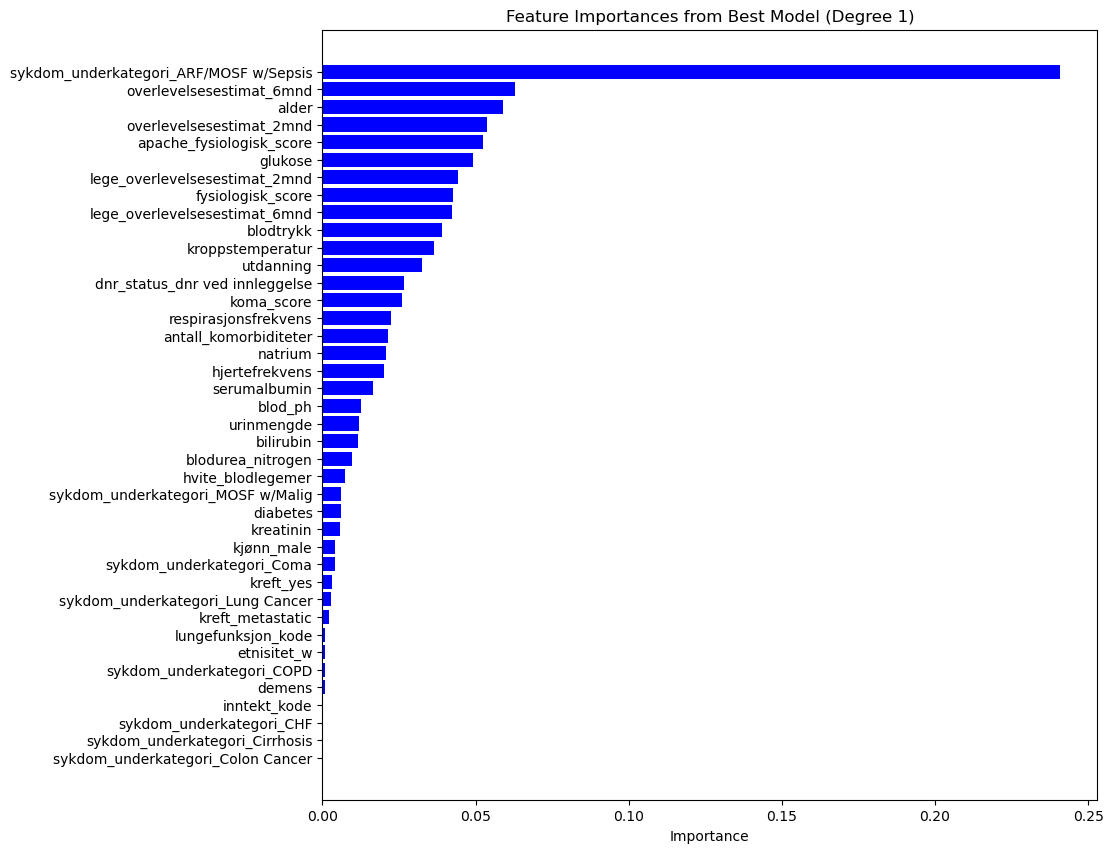

In [2333]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='blue')
plt.xlabel('Importance')
plt.title('Feature Importances from Best Model (Degree 1)')
plt.gca().invert_yaxis()
plt.show()


Kan først nå regne ut test-RSME på den endelige modellen med optimaliserte hyperparametere for å få et objektiv resultat på generaliseringsevnen:

In [2334]:
best_model.fit(X_train, y_train.values.ravel())

y_test_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 16.5715


For å få en bedre forståelse av modellens prestasjoner, både der den gjør nøyaktige prediksjoner og der den feiler, oppretter jeg en DataFrame som sammenligner prediksjonene med de faktiske oppholdslengdene i testsettet. Dette vil belyse både de tilfellene der modellen avviker betydelig og de der den presterer godt. For tolkning av resultatene, se rapport.

In [2335]:
errors = y_test_pred - y_test.values.ravel()

results_df = pd.DataFrame({
    'Actual Length': y_test.values.ravel(),
    'Predicted Length': y_test_pred,
    'Error': errors
})

large_error_threshold = 30  # Terskel for store feil
small_error_threshold = 3   # Terskel for små feil

large_errors = results_df[abs(results_df['Error']) > large_error_threshold]
small_errors = results_df[abs(results_df['Error']) <= small_error_threshold]

Til sammenligning printer jeg median oppholdslengde i treningssettet:

In [2336]:
y_train.median()

oppholdslengde    11.0
dtype: float64

Store prediksjonsfeil:

In [2337]:
print(large_errors.median())

Actual Length       69.00000
Predicted Length    23.85329
Error              -45.14671
dtype: float64


Små prediksjonsfeil:

In [2338]:
print(small_errors.median())

Actual Length       12.000000
Predicted Length    11.866910
Error                0.731308
dtype: float64


In [2339]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
with (ARTIFACTS_DIR / 'model.pkl').open('wb') as model_file:
    pickle.dump(best_model, model_file)
sample_df.to_csv(PROCESSED_DATA_DIR / 'final_sample_df.csv', index=False)